In [37]:
from scipy import stats
import pandas as pd
def mere(x:pd.Series)->dict:
    x=pd.to_numeric(x,errors="coerce").dropna().astype(float)

    positive = x[x>0]

    summary = stats.describe(x)

    q3=x.quantile(q=0.75)
    q1=x.quantile(q=0.25)

    strana = None
    asimetrija = stats.variation(x)

    if asimetrija>0:
        strana="desno"
    else:
        strana="levo"

    return{
        "n":len(x),
        "aritmeticka_sredina":x.mean(),
        "geometrijska_sredina":stats.gmean(x),
        "harmonijska_sredina":stats.hmean(x),
        "10_perc_trimovana":stats.trim_mean(x,proportiontocut=0.1),
        "raspon":x.describe().loc['max']-x.describe().loc['min'],
        "varijansa_uzorka":x.var(),
        "std_devijacija":x.std(),
        "IQR":q3-q1,
        "koeficijent_varijacije_perc":asimetrija,
        "asimetrija":stats.skew(x),
        "spljostenost":stats.kurtosis(x,bias=False),
        "q1":q1,
        "q3":q3,
        "p95":x.quantile(0.95),
        "mod":x.mode().iloc[0],
        "medijana":x.median(),
        "strana_asimetrije":strana
    }

In [38]:
df = pd.read_csv("korisnici_clean.csv",
                 parse_dates=["datum_aktivacije"])
for cat in ["region","pol", "tip_paketa", "kanal_prodaje", "churn"]:
    df[cat]=df[cat].astype("category")
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   id_korisnika               1200 non-null   str           
 1   region                     1200 non-null   category      
 2   pol                        1200 non-null   category      
 3   godine                     1200 non-null   int64         
 4   tip_paketa                 1200 non-null   category      
 5   staz_meseci                1200 non-null   float64       
 6   mesecni_racun_rsd          1200 non-null   float64       
 7   potrosnja_gb               1200 non-null   float64       
 8   minuti_poziva              1200 non-null   float64       
 9   broj_sms                   1200 non-null   float64       
 10  broj_reklamacija           1200 non-null   int64         
 11  kanal_prodaje              1200 non-null   category      
 12  datum_aktivacije 

## Univarijantna analiza

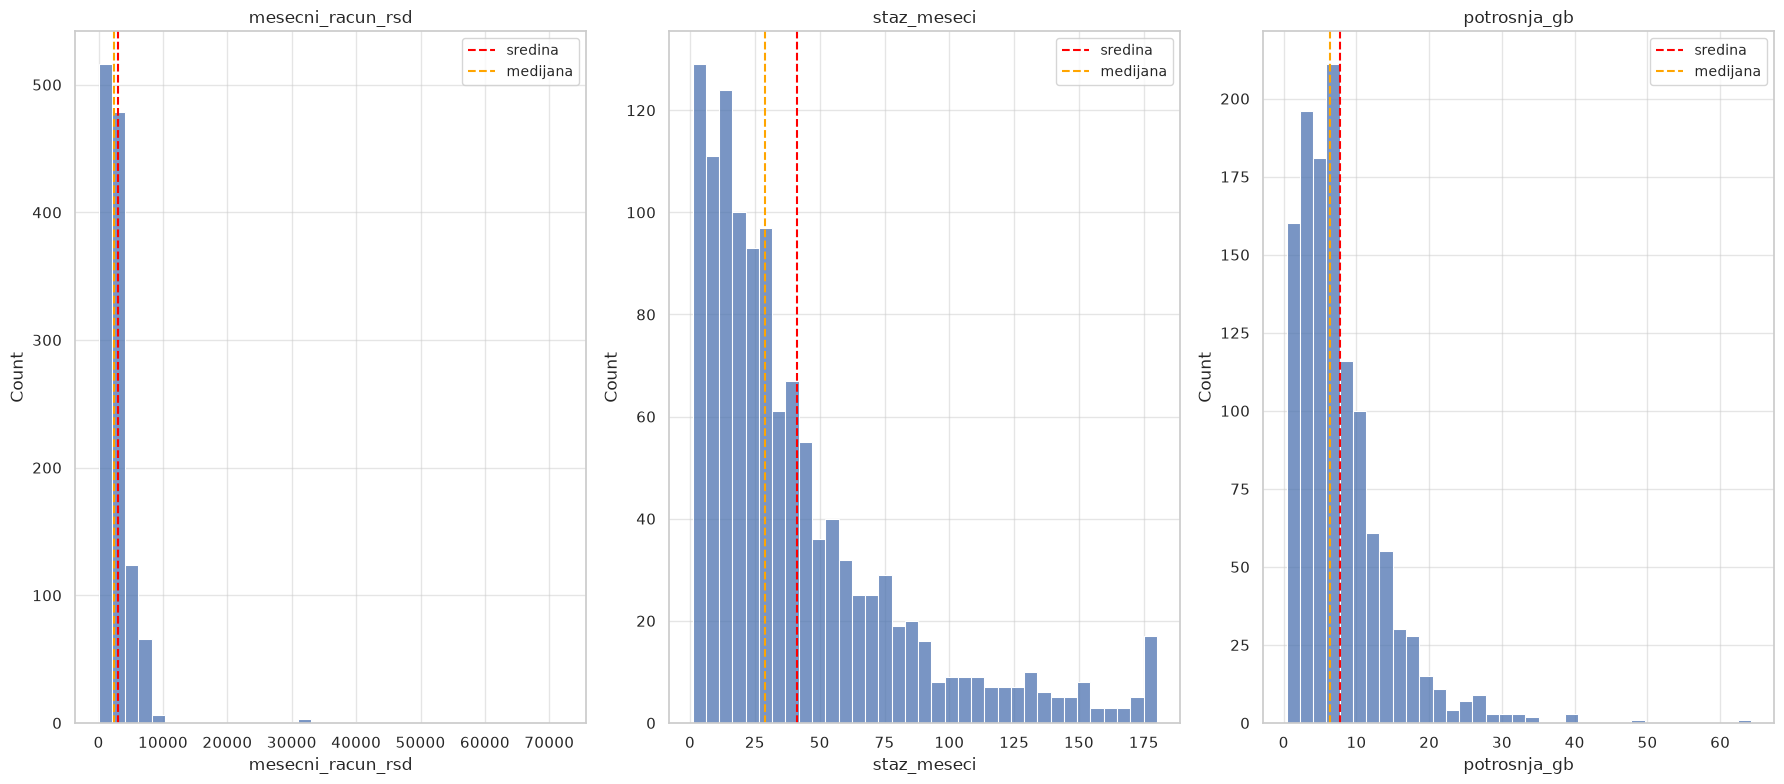

In [39]:
# Boxplot i histogram za numericke
import matplotlib.pyplot as plt, seaborn as sb

numeric=["mesecni_racun_rsd","staz_meseci","potrosnja_gb"]

sb.set_theme(style="whitegrid")

fig,ax=plt.subplots(1,3,figsize=(18,8))

for a, col in zip(ax.flat,numeric):
    sb.histplot(df[col].dropna(),ax=a,bins=35)
    a.axvline(x=df[col].mean(),linestyle="--",label="sredina",color="red")
    a.axvline(x=df[col].median(),linestyle="--",label="medijana",color="orange")
    a.set_title(col)
    a.legend(loc="upper right",fontsize="small")
plt.tight_layout()


In [40]:
for col in numeric:
    results=mere(df[col])
    print(f"{col}:\t{results["aritmeticka_sredina"]}, {results["medijana"]}, {results["asimetrija"]} {(results["strana_asimetrije"])}")

mesecni_racun_rsd:	2943.353335, 2380.0, 10.882733985595639 desno
staz_meseci:	41.43, 29.0, 1.620735055922035 desno
potrosnja_gb:	7.754499999999999, 6.4, 2.306250227365975 desno


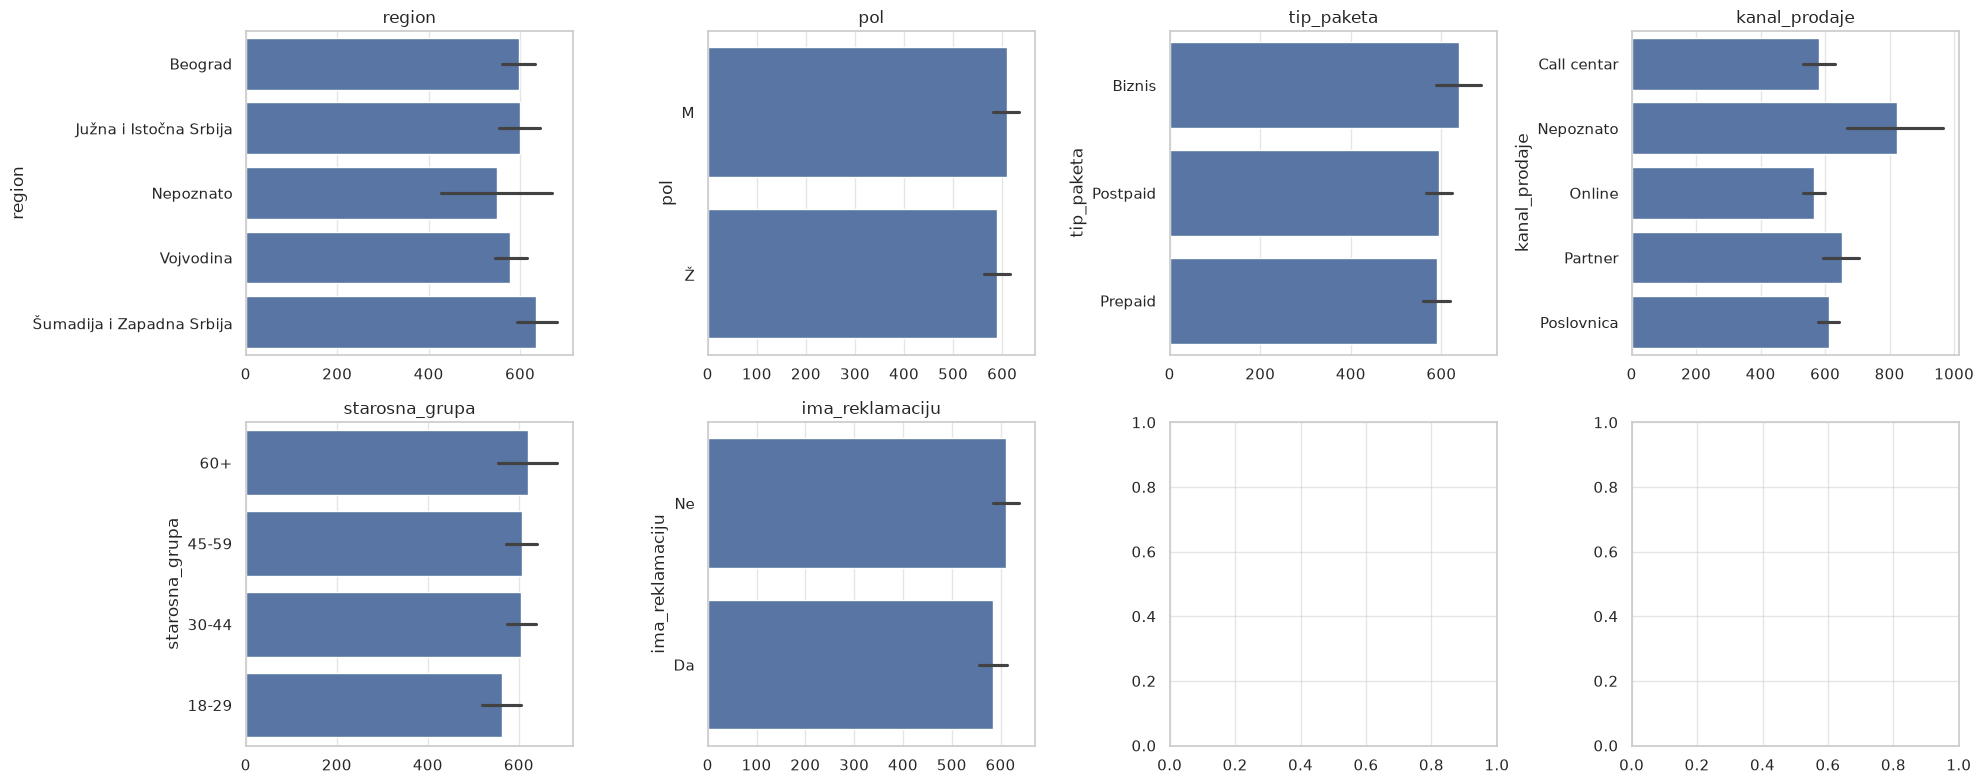

In [41]:
categories = ["region","pol","tip_paketa","kanal_prodaje","starosna_grupa","ima_reklamaciju"]

fig,ax=plt.subplots(2,4,figsize=(20,8))

for a, col in zip(ax.flat,categories):
    sb.barplot(df[col],ax=a,legend=True)
    a.set_title(col)

plt.tight_layout()

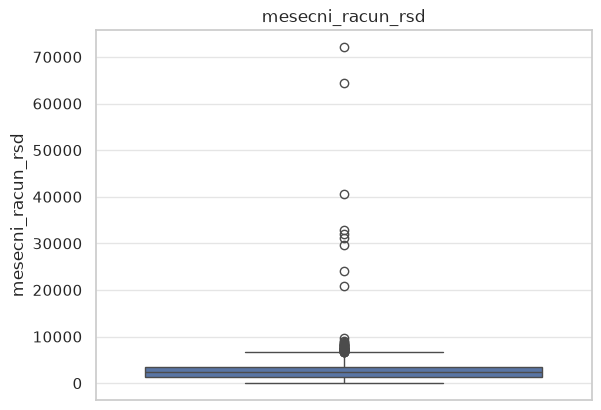

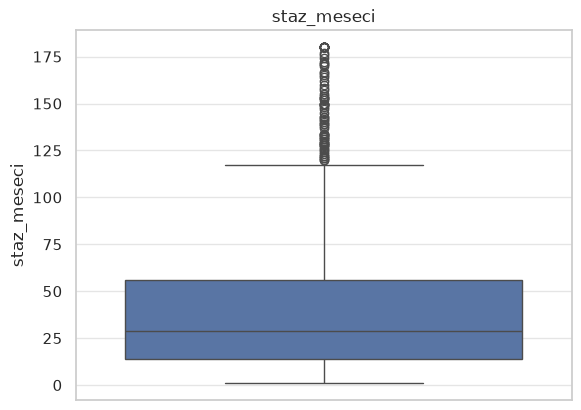

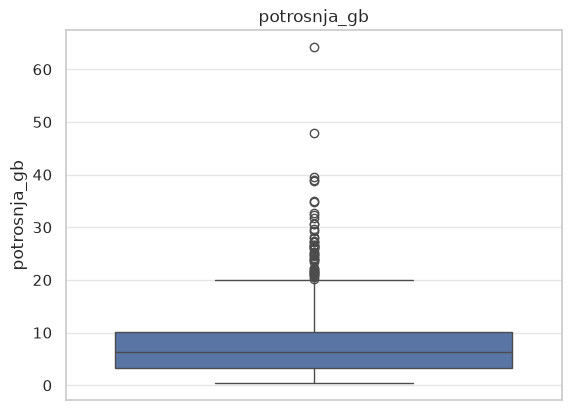

In [42]:

for col in numeric:
    plt.figure()
    plt.title(col)
    sb.boxplot(data=df[col])

    plt.show()


In [43]:
results_clean=[]

for col in numeric:
    results_clean.append(mere(df[col]))

categories = ["region","pol","tip_paketa","kanal_prodaje","starosna_grupa"]

## Churn po segmentima

In [44]:
cond = df["churn"]=="Da"
print(f" Ukupno:\t{df.loc[cond,"churn"].value_counts()["Da"]/len(df["churn"])*100}%, n={len(df)}")


group_cats=["pol","tip_paketa","kanal_prodaje","starosna_grupa","staz_grupa"] #ubaci i "region"
group_report=[]

for cat in group_cats:
    percent = df.groupby(cat,observed=True)["churn_flag"].agg(n="count",stopa="mean").reset_index()
    percent['stopa']*=100
    group_report.append(percent)

print("-----\nNajvece stope:\n")

for elem in group_report:
    cond = elem["n"]>100
    valid = elem.loc[cond] # same vrednosti
    index = valid["stopa"].idxmax() # index-i po kojima gledam
    print(elem.columns[0],valid.loc[index,elem.columns[0]],valid.loc[index,"stopa"])


 Ukupno:	22.25%, n=1200
-----
Najvece stope:

pol Ž 22.982456140350877
tip_paketa Prepaid 29.555555555555557
kanal_prodaje Partner 24.285714285714285
starosna_grupa 30-44 24.791666666666668
staz_grupa go 1 god 32.69961977186312


In [45]:
# Poredjenje medijana
numeric=["mesecni_racun_rsd","staz_meseci","potrosnja_gb","godine","broj_reklamacija","ocena_zadovoljstva"]

diff=df.groupby("churn")[["mesecni_racun_rsd","staz_meseci","potrosnja_gb","godine","broj_reklamacija","ocena_zadovoljstva"]].median()
display(diff)

,mesecni_racun_rsd,staz_meseci,potrosnja_gb,godine,broj_reklamacija,ocena_zadovoljstva
churn,,,,,,
Da,2119.0,21.0,6.4,41.0,1.0,3.0
Ne,2443.0,31.0,6.4,43.0,0.0,4.0


Ocito je da `ocena_zadovoljstva` izmedju `3` i `4` je prelomni trenutak.

## Korelacije

Оčito da ću morati da koristim `Spearman`-ovu korelaciju budući da imamo masu promenljivih koje su nenormalno raspoređene. Utvrđeno je u `01_profilisanje.ipynb`, a uz put smo i računali asimetriju koja je dosta daleko od nule.

ocena_zadovoljstva   -0.31
staz_meseci          -0.14
mesecni_racun_rsd    -0.09
godine               -0.02
potrosnja_gb         -0.00
broj_reklamacija      0.30
Name: churn_flag, dtype: float64


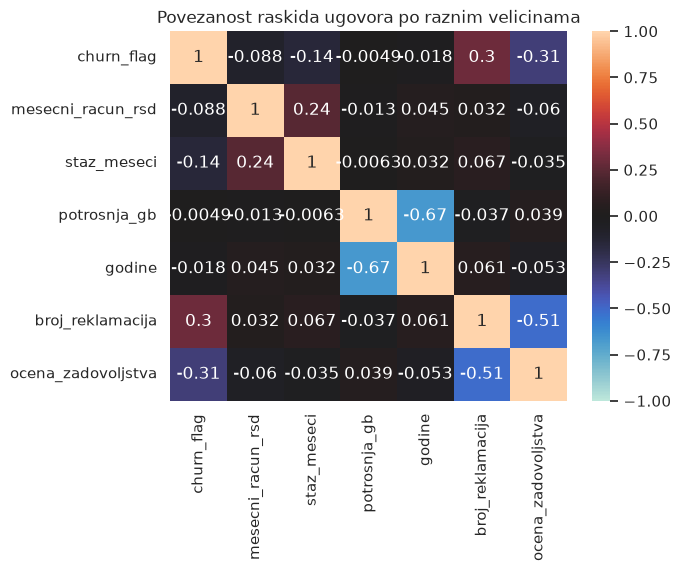

In [46]:

numeric=["mesecni_racun_rsd","staz_meseci","potrosnja_gb","godine","broj_reklamacija","ocena_zadovoljstva"]
corr = df[["churn_flag"]+numeric].corr(method="spearman")

print(round(corr["churn_flag"].drop("churn_flag"),2).sort_values())

plt.figure()
plt.title("Povezanost raskida ugovora po raznim velicinama")
sb.heatmap(data=corr,annot=True,center=0,vmin=-1,vmax=1)
plt.show()



In [49]:
for cat in ["ima_reklamaciju","ima_potrosnje","staz_grupa","starosna_grupa"]:
    df[cat]=df[cat].astype("category")
display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   id_korisnika               1200 non-null   str           
 1   region                     1200 non-null   category      
 2   pol                        1200 non-null   category      
 3   godine                     1200 non-null   int64         
 4   tip_paketa                 1200 non-null   category      
 5   staz_meseci                1200 non-null   float64       
 6   mesecni_racun_rsd          1200 non-null   float64       
 7   potrosnja_gb               1200 non-null   float64       
 8   minuti_poziva              1200 non-null   float64       
 9   broj_sms                   1200 non-null   float64       
 10  broj_reklamacija           1200 non-null   int64         
 11  kanal_prodaje              1200 non-null   category      
 12  datum_aktivacije 

None

## Testiranje hipoteza

1) Da li se neki paketi preferiraju u nekom kanalu prodaje ?

In [84]:
from scipy.stats import chi2_contingency

cont_tb = pd.crosstab(df["tip_paketa"],df["kanal_prodaje"],normalize="index") #index->raspodela po kanalima

chi2,p,dof,expected = chi2_contingency(cont_tb)

print(f"{p}")


0.9999999985798643


Očito je da $0.99>>0.05$ tj možemo da kažemo da NE postoji osnovana sumnja u povezanost izbora paketa prema kanalu prodaje.

In [ ]:
# Countplot

2) Da li na odlazak pre godinu dana ima uticaj kanal prodaje kojim je ugovoren paket ? (`churn` naspram `kanal_prodaje`)

In [65]:
cont_tb = pd.crosstab(df["churn_flag"],df["kanal_prodaje"],normalize=True)

chi2,p,dof,expected = chi2_contingency(cont_tb)

print(f"{chi2:.3f}, {p:.3f}, {dof:.3f}")


0.001, 1.000, 4.000


Ne postoji osnovana sumnja da je kanal prodaje povezan sa ranim gubitkom korisnika.

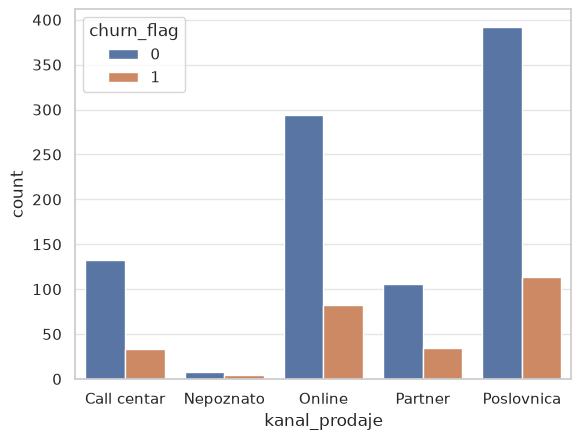

In [82]:
# Countplot
plt.figure()

sb.countplot(data=df,x="kanal_prodaje",hue="churn_flag")

plt.show()

3) Da li više melju preko telefona muškarci i žene ? Poredimo po starosnim grupama (malopre utvrđenim)

In [85]:
from scipy.stats import mannwhitneyu

frame = df.loc[df["tip_paketa"]!="Biznis"].copy().groupby("starosna_grupa",observed=True)

for group,df_group in frame:
    talk_men = df_group.loc[df_group["pol"]=="M","minuti_poziva"]
    talk_women = df_group.loc[df_group["pol"]=="Ž","minuti_poziva"]

    u,p = mannwhitneyu(talk_men,talk_women,alternative="two-sided") # mislimo da ima razlike u rangovima

    print(f"{group} {round(p,2)>0.05}")

18-29 True
30-44 True
45-59 True
60+ True


Vidimo da broj minuta priče preko telefona je manje/više isti. Pri tome, `Biznis` korisnici su isključeni iz analize, jer ne možemo znati nužno da li se telefon vodi na radnika ili na firmu.

4) Da li starosna grupa opredeljuje izbor paketa ?

In [83]:
cont_tb = pd.crosstab(df["starosna_grupa"],df["tip_paketa"],normalize=True)

chi2,p,dof,expected = chi2_contingency(cont_tb)

print(f"{chi2:.3f}, {p:.3f}, {dof:.3f}")

0.005, 1.000, 6.000


Ne postoji razlog za sumnju za ovakvu vrstu opredeljenosti.

5) Pregled minutaže po starosnim grupama i utvrđivanje povezanosti

In [115]:
frame = df.groupby("starosna_grupa",observed=True)

from scipy.stats import shapiro,kruskal

res = shapiro(df["minuti_poziva"])

print(f"Nenormalnost raspodele minutaze: {res.pvalue<0.05}")

samples = []

for name, data in frame:
    mins=grupa["minuti_poziva"]
    samples.append(mins)

H, p = stats.kruskal(samples)

print("H =", H)
print("Odbacuje se hipoteza: ", p<0.05)

Nenormalnost raspodele minutaze: True
H = 451.0000000000001
Odbacuje se hipoteza:  True


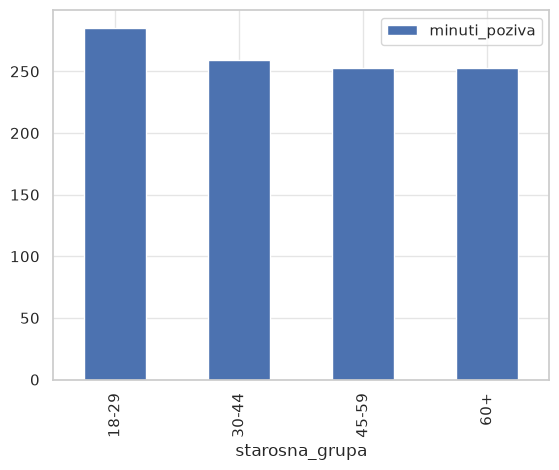

In [129]:
medians = pd.DataFrame(frame["minuti_poziva"].median())

medians.plot(kind="bar")

plt.show()

